In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data

In [ ]:
here

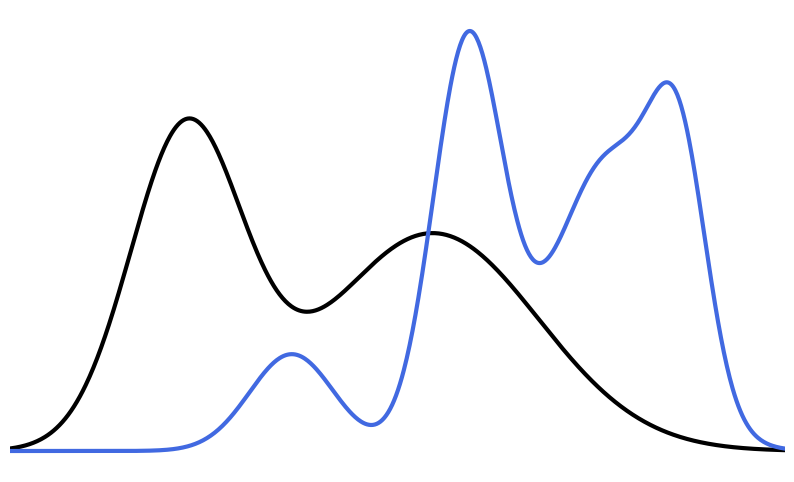

/tmp/ipykernel_410128/3427467763.py:119: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_410128/3427467763.py:119: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_410128/3427467763.py:119: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_410128/3427467763.py:119: UserWarning: Glyph 49900 (\N{HANGUL SYLLABLE SIM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_410128/3427467763.py:119: UserWarning: Glyph 46160 (\N{HANGUL SYLLABLE DU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_410128/3427467763.py:119: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_410128/3427467763.py:119: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu 

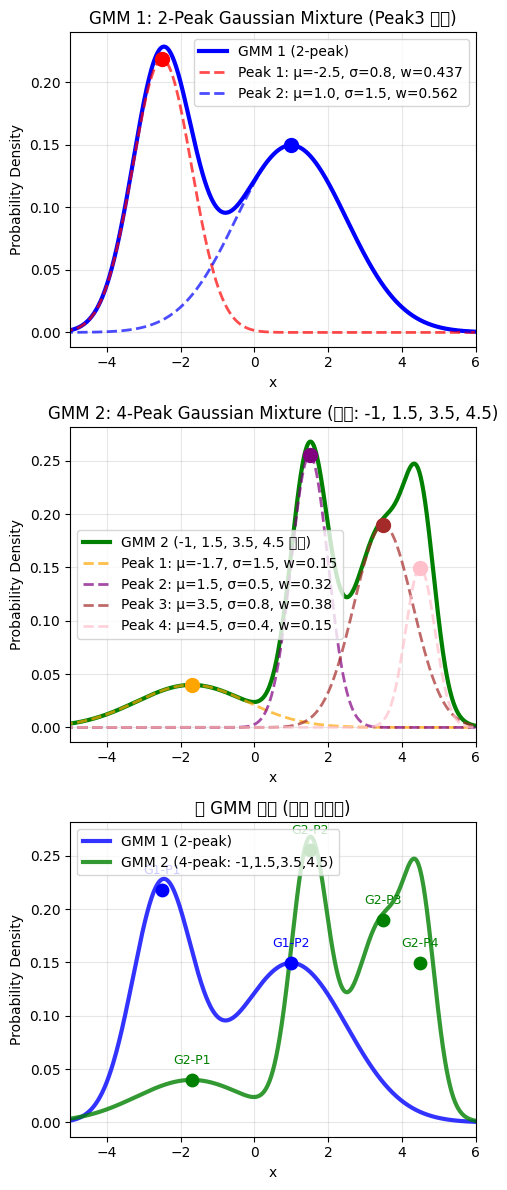

=== 두 GMM 비교 ===

🔵 GMM 1 (Peak3 제거된 2-peak):
  Peak 위치: [-2.5  1. ]
  Peak 폭: [0.8 1.5]
  Peak 가중치: [0.4375 0.5625]
  가중치 합: 1.000

  각 Peak 높이:
    Peak 1: 0.2182
    Peak 2: 0.1496

🟢 GMM 2 (4-peak, 중심: -1, 1.5, 3.5, 4.5):
  Peak 위치: [-1.7  1.5  3.5  4.5]
  Peak 폭: [1.5 0.5 0.8 0.4]
  Peak 가중치: [0.15 0.32 0.38 0.15]
  가중치 합: 1.000

  각 Peak 높이:
    Peak 1: 0.0399
    Peak 2: 0.2553
    Peak 3: 0.1895
    Peak 4: 0.1496

📊 분포 통계 비교:
  GMM 1 - 최대값: 0.2284, 최소값: 0.000018
  GMM 2 - 최대값: 0.2680, 최소값: 0.000655
  GMM 1 적분값: 0.9998
  GMM 2 적분값: 0.9993

두 GMM 결과가 'gmm_results' 딕셔너리에 저장되었습니다.
  사용법: gmm_results['gmm1']['pdf'], gmm_results['gmm2']['pdf']


/tmp/ipykernel_410128/3427467763.py:149: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  GMM 1 적분값: {np.trapz(gmm1_pdf, x):.4f}")
/tmp/ipykernel_410128/3427467763.py:150: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  GMM 2 적분값: {np.trapz(gmm2_pdf, x):.4f}")


In [118]:
# GMM 생성
means1 = np.array([-2.5, 1.0])
stds1 = np.array([0.8, 1.5])    
weights1 = np.array([0.35, 0.45])  
weights1 = weights1 / np.sum(weights1)

means2 = np.array([-1.0, 1.5, 3.5, 4.5])
stds2 = np.array([0.6, 0.5, 0.8, 0.4])
weights2 = np.array([0.1, 0.35, 0.4, 0.15])

x = np.linspace(-5, 6, 800)

# GMM 계산
gmm1_pdf = np.sum([weights1[i] * scipy.stats.norm.pdf(x, means1[i], stds1[i]) for i in range(len(means1))], axis=0)
gmm2_pdf = np.sum([weights2[i] * scipy.stats.norm.pdf(x, means2[i], stds2[i]) for i in range(len(means2))], axis=0)

# 시각화
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, gmm1_pdf, color='black', linewidth=3)
ax.plot(x, gmm2_pdf, color='royalblue', linewidth=3)
ax.set_xlim(-5, 6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
plt.show()



# GMM 2: -1, 1.5, 3.5, 4.5에 중심을 둔 4-peak GMM (네 번째 peak 추가)
means2 = np.array([-1.7, 1.5, 3.5, 4.5])
stds2 = np.array([1.5, 0.5, 0.8, 0.4])    # 서로 다른 폭
weights2 = np.array([0.15, 0.32, 0.38, 0.15])  # 가중치 (첫 번째가 가장 낮음, 합이 1)

# 적절한 x 범위 설정 (peak들을 포함하되 더 컴팩트하게)
x = np.linspace(-6, 6, 800)

# GMM 1 계산
gmm1_components = []
for i in range(len(means1)):
    component = weights1[i] * scipy.stats.norm.pdf(x, means1[i], stds1[i])
    gmm1_components.append(component)
gmm1_pdf = np.sum(gmm1_components, axis=0)

# GMM 2 계산  
gmm2_components = []
for i in range(len(means2)):
    component = weights2[i] * scipy.stats.norm.pdf(x, means2[i], stds2[i])
    gmm2_components.append(component)
gmm2_pdf = np.sum(gmm2_components, axis=0)

# 시각화
fig, axes = plt.subplots(3, 1, figsize=(5, 12))

# 1. GMM 1 (2-peak) 상세
axes[0].plot(x, gmm1_pdf, 'b-', linewidth=3, label='GMM 1 (2-peak)')
colors1 = ['red', 'blue']
for i in range(len(means1)):
    axes[0].plot(x, gmm1_components[i], '--', color=colors1[i], linewidth=2, alpha=0.7,
                label=f'Peak {i+1}: μ={means1[i]}, σ={stds1[i]}, w={weights1[i]:.3f}')
    # peak 지점 표시
    peak_height = weights1[i] * scipy.stats.norm.pdf(means1[i], means1[i], stds1[i])
    axes[0].scatter(means1[i], peak_height, color=colors1[i], s=100, zorder=5)

axes[0].set_xlabel('x')
axes[0].set_ylabel('Probability Density')
axes[0].set_title('GMM 1: 2-Peak Gaussian Mixture (Peak3 제거)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(-5, 6)

# 2. GMM 2 (-1, 1.5, 3.5, 4.5 중심) 상세  
axes[1].plot(x, gmm2_pdf, 'g-', linewidth=3, label='GMM 2 (-1, 1.5, 3.5, 4.5 중심)')
colors2 = ['orange', 'purple', 'brown', 'pink']
for i in range(len(means2)):
    axes[1].plot(x, gmm2_components[i], '--', color=colors2[i], linewidth=2, alpha=0.7,
                label=f'Peak {i+1}: μ={means2[i]}, σ={stds2[i]}, w={weights2[i]}')
    # peak 지점 표시
    peak_height = weights2[i] * scipy.stats.norm.pdf(means2[i], means2[i], stds2[i])
    axes[1].scatter(means2[i], peak_height, color=colors2[i], s=100, zorder=5)

axes[1].set_xlabel('x')
axes[1].set_ylabel('Probability Density') 
axes[1].set_title('GMM 2: 4-Peak Gaussian Mixture (중심: -1, 1.5, 3.5, 4.5)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(-5, 6)

# 3. 두 GMM을 같은 그래프에 
axes[2].plot(x, gmm1_pdf, 'b-', linewidth=3, label='GMM 1 (2-peak)', alpha=0.8)
axes[2].plot(x, gmm2_pdf, 'g-', linewidth=3, label='GMM 2 (4-peak: -1,1.5,3.5,4.5)', alpha=0.8)

# 모든 peak 위치 표시
# GMM 1 peaks
for i in range(len(means1)):
    peak_height = weights1[i] * scipy.stats.norm.pdf(means1[i], means1[i], stds1[i])
    axes[2].scatter(means1[i], peak_height, color='blue', s=80, zorder=5)
    axes[2].annotate(f'G1-P{i+1}', xy=(means1[i], peak_height), 
                    xytext=(means1[i], peak_height + 0.015),
                    ha='center', fontsize=9, color='blue')

# GMM 2 peaks  
for i in range(len(means2)):
    peak_height = weights2[i] * scipy.stats.norm.pdf(means2[i], means2[i], stds2[i])
    axes[2].scatter(means2[i], peak_height, color='green', s=80, zorder=5)
    axes[2].annotate(f'G2-P{i+1}', xy=(means2[i], peak_height), 
                    xytext=(means2[i], peak_height + 0.015),
                    ha='center', fontsize=9, color='green')

axes[2].set_xlabel('x')
axes[2].set_ylabel('Probability Density')
axes[2].set_title('두 GMM 비교 (같은 그래프)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(-5, 6)

plt.tight_layout()
plt.show()

# 두 GMM 정보 출력
print("=== 두 GMM 비교 ===")
print("\n🔵 GMM 1 (Peak3 제거된 2-peak):")
print(f"  Peak 위치: {means1}")
print(f"  Peak 폭: {stds1}")
print(f"  Peak 가중치: {weights1}")
print(f"  가중치 합: {np.sum(weights1):.3f}")

print(f"\n  각 Peak 높이:")
for i in range(len(means1)):
    actual_height = weights1[i] * scipy.stats.norm.pdf(means1[i], means1[i], stds1[i])
    print(f"    Peak {i+1}: {actual_height:.4f}")

print(f"\n🟢 GMM 2 (4-peak, 중심: -1, 1.5, 3.5, 4.5):")
print(f"  Peak 위치: {means2}")
print(f"  Peak 폭: {stds2}")  
print(f"  Peak 가중치: {weights2}")
print(f"  가중치 합: {np.sum(weights2):.3f}")

print(f"\n  각 Peak 높이:")
for i in range(len(means2)):
    actual_height = weights2[i] * scipy.stats.norm.pdf(means2[i], means2[i], stds2[i])
    print(f"    Peak {i+1}: {actual_height:.4f}")

print(f"\n📊 분포 통계 비교:")
print(f"  GMM 1 - 최대값: {np.max(gmm1_pdf):.4f}, 최소값: {np.min(gmm1_pdf):.6f}")
print(f"  GMM 2 - 최대값: {np.max(gmm2_pdf):.4f}, 최소값: {np.min(gmm2_pdf):.6f}")
print(f"  GMM 1 적분값: {np.trapz(gmm1_pdf, x):.4f}")
print(f"  GMM 2 적분값: {np.trapz(gmm2_pdf, x):.4f}")

# 결과를 변수로 저장
gmm_results = {
    'x': x,
    'gmm1': {
        'pdf': gmm1_pdf,
        'means': means1,
        'stds': stds1, 
        'weights': weights1,
        'components': gmm1_components
    },
    'gmm2': {
        'pdf': gmm2_pdf,
        'means': means2,
        'stds': stds2,
        'weights': weights2,
        'components': gmm2_components
    }
}

print(f"\n두 GMM 결과가 'gmm_results' 딕셔너리에 저장되었습니다.")
print(f"  사용법: gmm_results['gmm1']['pdf'], gmm_results['gmm2']['pdf']")


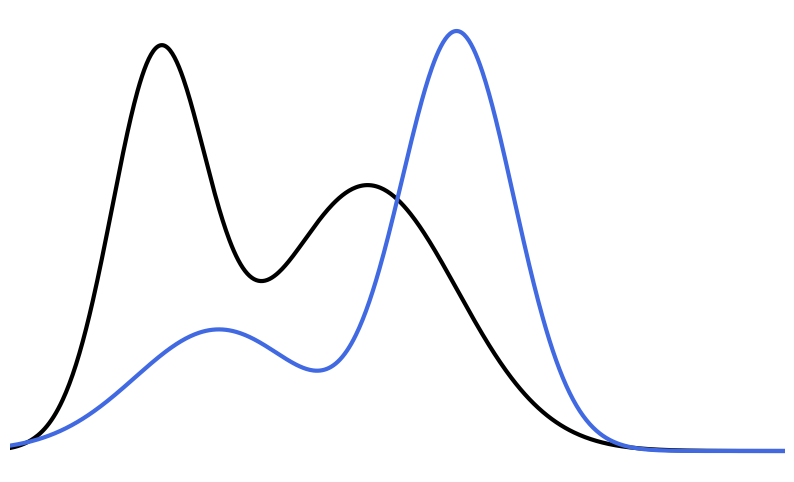

In [ ]:
# GMM 생성
means1 = np.array([-2.5, 1.0])
stds1 = np.array([0.8, 1.5])    
weights1 = np.array([0.35, 0.45])  
weights1 = weights1 / np.sum(weights1)

means2 = np.array([-1.5, 2.5])
stds2 = np.array([1.4, 0.95])
weights2 = np.array([0.24, 0.56])

x = np.linspace(-5, 10, 800)

# GMM 계산
gmm1_pdf = np.sum([weights1[i] * scipy.stats.norm.pdf(x, means1[i], stds1[i]) for i in range(len(means1))], axis=0)
gmm2_pdf = np.sum([weights2[i] * scipy.stats.norm.pdf(x, means2[i], stds2[i]) for i in range(len(means2))], axis=0)

# 시각화
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('none')  # figure 배경 투명
ax.patch.set_facecolor('none')   # axes 배경 투명
ax.plot(x, gmm1_pdf, color='black', linewidth=3)
ax.plot(x, gmm2_pdf, color='royalblue', linewidth=3)
ax.set_xlim(-5, 8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
plt.show()


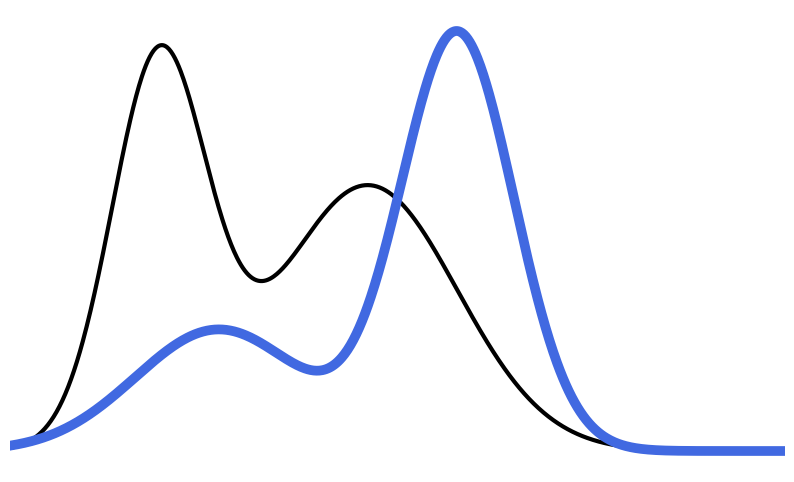

In [209]:
# GMM 생성
means1 = np.array([-2.5, 1.0])
stds1 = np.array([0.8, 1.5])    
weights1 = np.array([0.35, 0.45])  
weights1 = weights1 / np.sum(weights1)

means2 = np.array([-1.5, 2.5])
stds2 = np.array([1.4, 0.95])
weights2 = np.array([0.24, 0.56])

x = np.linspace(-5, 8, 800)

# GMM 계산
gmm1_pdf = np.sum([weights1[i] * scipy.stats.norm.pdf(x, means1[i], stds1[i]) for i in range(len(means1))], axis=0)
gmm2_pdf = np.sum([weights2[i] * scipy.stats.norm.pdf(x, means2[i], stds2[i]) for i in range(len(means2))], axis=0)

# 시각화
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('none')  # figure 배경 투명
ax.patch.set_facecolor('none')   # axes 배경 투명
ax.plot(x, gmm1_pdf, color='black', linewidth=3)
ax.plot(x, gmm2_pdf, color='royalblue', linewidth=7)
ax.set_xlim(-5, 8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
plt.show()



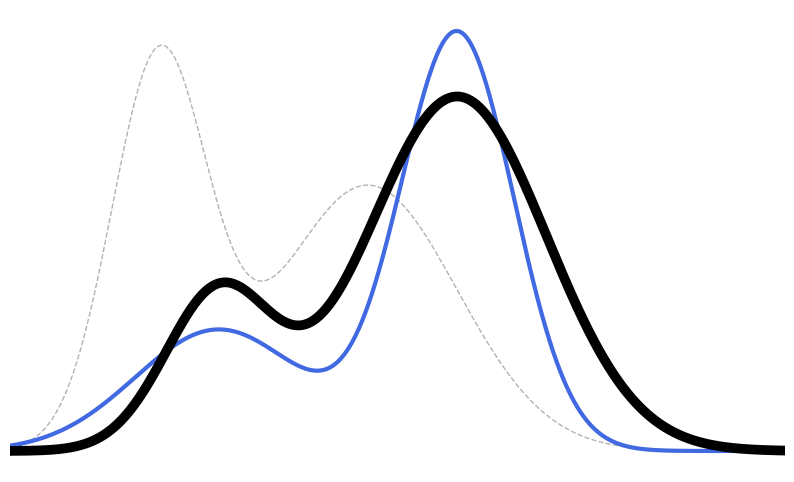

In [210]:
# GMM 생성
means1 = np.array([-2.5, 1.0])
stds1 = np.array([0.8, 1.5])    
weights1 = np.array([0.35, 0.45])  
weights1 = weights1 / np.sum(weights1)

means2 = np.array([-1.5, 2.5])
stds2 = np.array([1.4, 0.95])
weights2 = np.array([0.24, 0.56])

means3 = np.array([-1.5, 2.5])
stds3 = np.array([0.9, 1.5])    
weights3 = np.array([0.2, 0.75])  

x = np.linspace(-5, 8, 800)

# GMM 계산
gmm1_pdf = np.sum([weights1[i] * scipy.stats.norm.pdf(x, means1[i], stds1[i]) for i in range(len(means1))], axis=0)
gmm2_pdf = np.sum([weights2[i] * scipy.stats.norm.pdf(x, means2[i], stds2[i]) for i in range(len(means2))], axis=0)
gmm3_pdf = np.sum([weights3[i] * scipy.stats.norm.pdf(x, means3[i], stds3[i]) for i in range(len(means3))], axis=0)
# 시각화
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('none')  # figure 배경 투명
ax.patch.set_facecolor('none')   # axes 배경 투명
ax.plot(x, gmm1_pdf, color='grey', linestyle = '--', linewidth=1, alpha=0.6)
ax.plot(x, gmm2_pdf, color='royalblue', linewidth=3)
ax.plot(x, gmm3_pdf, color='black', linewidth=7)
ax.set_xlim(-5, 8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
plt.show()


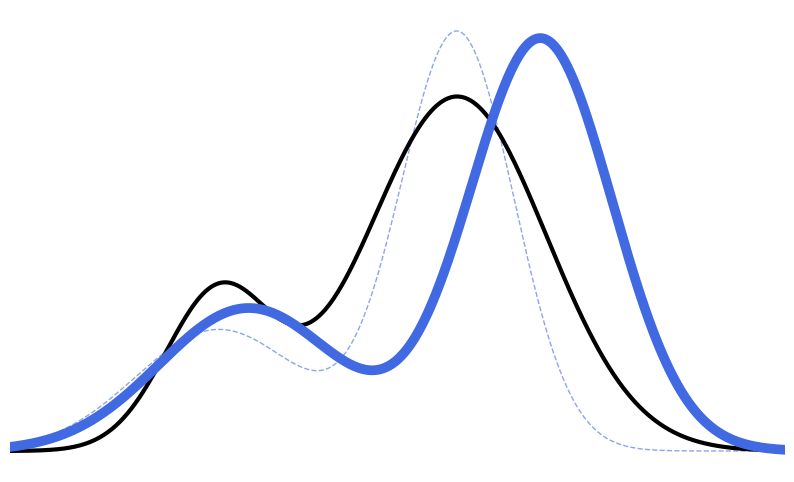

In [ ]:
# GMM 생성
means1 = np.array([-1.0, 3.9])
stds1 = np.array([1.5, 1.2])    
weights1 = np.array([0.26, 0.60])  
weights1 = weights1 / np.sum(weights1)

means2 = np.array([-1.5, 2.5])
stds2 = np.array([1.4, 0.95])
weights2 = np.array([0.24, 0.56])

means3 = np.array([-1.5, 2.5])
stds3 = np.array([0.9, 1.5])    
weights3 = np.array([0.2, 0.75])  


x = np.linspace(-5, 8, 800)

# GMM 계산
gmm1_pdf = np.sum([weights1[i] * scipy.stats.norm.pdf(x, means1[i], stds1[i]) for i in range(len(means1))], axis=0)
gmm2_pdf = np.sum([weights2[i] * scipy.stats.norm.pdf(x, means2[i], stds2[i]) for i in range(len(means2))], axis=0)
gmm3_pdf = np.sum([weights3[i] * scipy.stats.norm.pdf(x, means3[i], stds3[i]) for i in range(len(means3))], axis=0)
# 시각화
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('none')  # figure 배경 투명
ax.patch.set_facecolor('none')   # axes 배경 투명

ax.plot(x, gmm2_pdf, color='royalblue', linestyle = '--', linewidth=1, alpha=0.6)
ax.plot(x, gmm3_pdf, color='black', linewidth=3)
ax.plot(x, gmm1_pdf, color='royalblue', linewidth=7)

ax.set_xlim(-5, 8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
plt.show()